# Introduction

This code generates the figures for the paper "Interannual controls of the phytoplankton assemblages in Baffin Bay".

## Directory structure

binder, where is the .yml file for the conda virtual environment.

data, where are the observed winter nutrients from the Qikiqtarjuaq ice camps 2015 and 2016, the prescribed winter nutrients for the sensitivity experiments, the outputs of the model MITgcm and the observed winter nutrients for the 11 expeditions mentioned in Ardyna et al. (2020) in *Elem. Sci. Anth.*.

figures_assemblages_progress, where are the figures.

## Environment

This notebook was run in a conda virtual environment. The following commands will automatically create the environment and launch the Jupyter notebook:

```
cd <my_path>/assemblages
conda env create -f binder/environment_assemblages.yml
conda activate assemblages
jupyter notebook
```

Once the environment assemblages is created, the Jupyter notebook can be launched simply with:

```
cd <my_path>/assemblages
conda activate assemblages
jupyter notebook
```

# Code

## Load libraries

In [1]:
%matplotlib inline

import cycler
import matplotlib as mpl
import matplotlib.pyplot as plt
import netcdf_tools
import numpy as np
import os
import pandas as pd
import re

## Parameters for the figures

In [2]:
# dpi='figure' # default dpi
dpi=600
# ext='png'
ext='jpeg'

# Date of the simulations

This date of the simulations in the format yyyymmdd will be used to construct the names of the output files.

In [3]:
indir_outputs='data/DataS3_outputs_short'

In [4]:
pattern=\
'^groups\.run_(?P<yyyymmdd>\d{8})\w*_sims(?P<suffix>\w*)\.csv$'
regex=re.compile(pattern)
files=os.listdir(indir_outputs)
found=False
ifile=0
while(ifile<len(files) and not found):
    fname_example=files[ifile]
    match=regex.match(fname_example)
    if match!=None:
        found=True
        yyyymmdd=match.group('yyyymmdd')
        suffix=match.group('suffix')
    ifile=ifile+1
cwd=os.getcwd()
assert found, \
'current working directory %r contains no file with a name corresponding to %r' \
% (cwd,pattern)

In [5]:
fname_example

'groups.run_20240930_0000_EXP2_3no3_00_si_00_122_sims.csv'

In [6]:
yyyymmdd

'20240930'

In [7]:
suffix

''

## Depths

In [8]:
gridfile\
='data/DataS4_outputs_long/run_'\
+yyyymmdd\
+'_0000_EXP2_3si_standard_no3_standard_122_sims/grid.t001.nc'

In [9]:
RC=-netcdf_tools.read_netcdf(gridfile,'RC')

# Nitrate and silicate concentration profiles

In [10]:
infile_no3_standard\
='data/DataS1_winter_nutrients_in_situ_qik/1D_BB_NO3_GE_spring.delZ1016mm.32bits.bin'
infile_si_standard\
='data/DataS1_winter_nutrients_in_situ_qik/1D_BB_Si_GE_spring.delZ1016mm.32bits.bin'
no3_prefix\
='data/DataS2_winter_nutrients_simulated/1D_BB_NO3_GE_spring.delZ1016mm.32bits.'
si_prefix\
='data/DataS2_winter_nutrients_simulated/1D_BB_Si_GE_spring.delZ1016mm.32bits.'

In [11]:
array1d_idepth_no3_standard=np.fromfile(infile_no3_standard,
                                        dtype='>f')
array1d_idepth_si_standard=np.fromfile(infile_si_standard,
                                       dtype='>f')

Multiplying factors by which to multiply $NO_3$ at 100 m

In [12]:
no3_goals=np.arange(0,21,2)

Multiplying factors by which to multiply $\mathrm{ Si{(OH)}_4 }$ at 100 m

In [13]:
si_goals=np.arange(0,21,2)

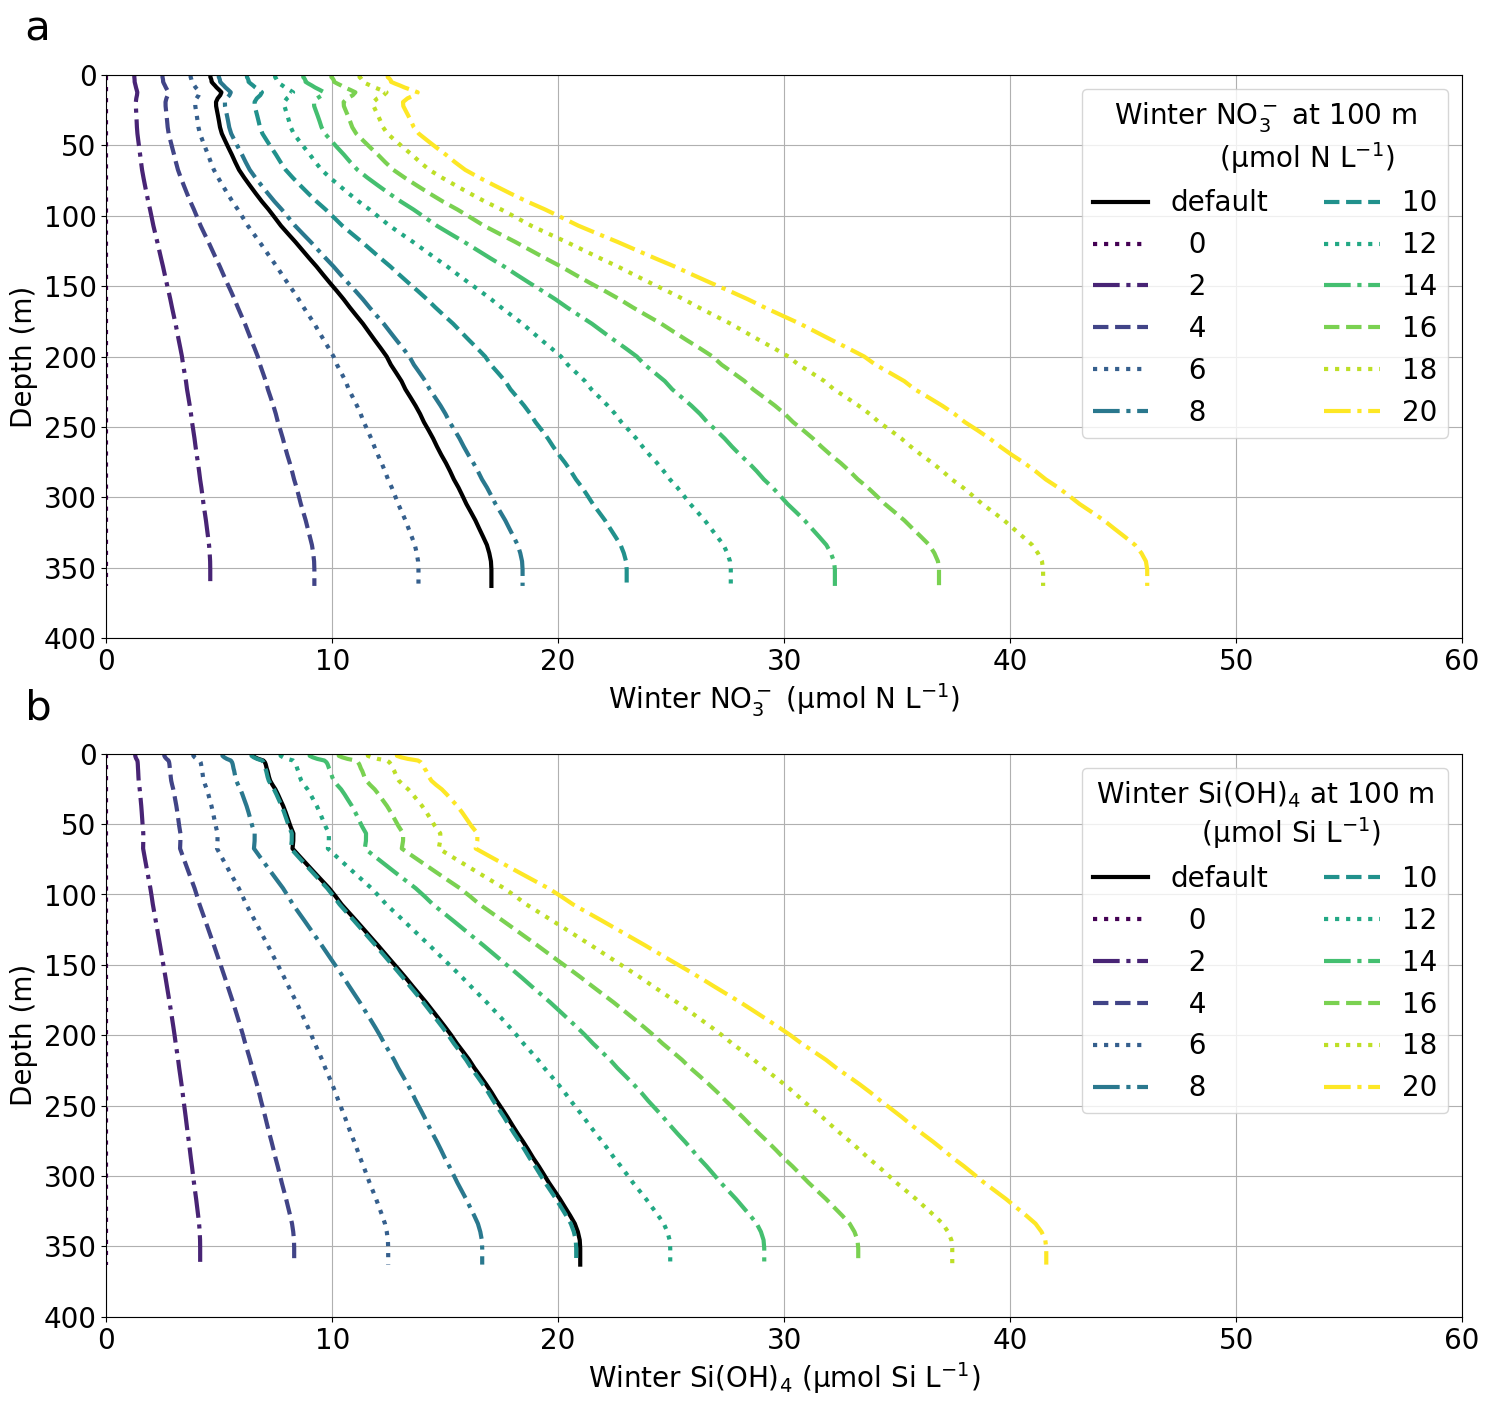

In [14]:
def make_plots(axs):
    box=dict(pad=5,alpha=0)
    
    # --- NITRATE
    ax=axs[0]
    # default
    ax.plot(array1d_idepth_no3_standard,RC,
            color='black',ls='-',label='default')
    ax.set_xlabel('Winter $\mathrm{ NO_3^-\ (\mu mol\ N\ L^{-1}) }$')
    ax.set_ylabel('Depth (m)')
    ax.set_xlim(0,60)
    ax.set_ylim(0,400)
    ax.invert_yaxis()
    ax.grid(True)
    plt.tight_layout()
    # sensitivity simulations
    cc=cycler.cycler(color=plt.cm.viridis(
        np.linspace(0,1,no3_goals.size)),
                     linestyle=[':','-.','--',':','-.','--',
                                ':','-.','--',':','-.'])
    ax.set_prop_cycle(cc)
    for no3_goal in no3_goals:
        label='{0:02}'.format(no3_goal)
        infile_no3=no3_prefix+label+'.bin'
        array1d_idepth_no3=np.fromfile(infile_no3,dtype='>f')
        label_nice=label
        if label.startswith('0'):
            label=label[1:]
            label_nice='  '+label
        ax.plot(array1d_idepth_no3,RC,label=label_nice)
    ax.legend(title='$\mathrm{ Winter\ NO_3^- }$ at 100 m\n            ($\mathrm{ \mu mol\ N\ L^{-1} }$)',
              ncol=2)
    plt.text(-0.05,1.08,' a ',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes, fontsize=30)
    
    # --- SILICATE
    ax=axs[1]
    # default
    ax.plot(array1d_idepth_si_standard,RC,
            color='black',ls='-',label='default')
    ax.set_xlabel('Winter $\mathrm{ Si(OH)_4\ (\mu mol\ Si\ L^{-1}) }$')
    ax.set_ylabel('Depth (m)')
    ax.set_xlim(0,60)
    ax.set_ylim(0,400)
    ax.invert_yaxis()
    ax.grid(True)
    plt.tight_layout()
    # sensitivity simulations
    cc=cycler.cycler(color=plt.cm.viridis(
        np.linspace(0,1,no3_goals.size)),
                     linestyle=[':','-.','--',':','-.','--',
                                ':','-.','--',':','-.'])
    ax.set_prop_cycle(cc)
    for si_goal in si_goals:
        label='{0:02}'.format(si_goal)
        infile_si=si_prefix+label+'.bin'
        array1d_idepth_si=np.fromfile(infile_si,dtype='>f')
        label_nice=label
        if label.startswith('0'):
            label=label[1:]
            label_nice='  '+label
        ax.plot(array1d_idepth_si,RC,label=label_nice)
    ax.legend(title='$\mathrm{ Winter\ Si(OH)_4 }$ at 100 m\n            ($\mathrm{ \mu mol\ Si\ L^{-1} }$)',
              ncol=2)
    plt.text(-0.05,1.08,' b ',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes, fontsize=30)
    
    # --- POSITION
    axs[0].set_position( [0.07,0.55  ,0.91,0.39])
    axs[1].set_position( [0.07,0.08  ,0.91,0.39])
    
with plt.style.context('mplstyles/data_rbcs.mplstyle'):
    # Plot
    fig,axs=plt.subplots(2,1,figsize=(14.90,14.44))
    make_plots(axs)

    # --- SAVE
    outfile='figures/figure1.'+ext
    plt.savefig(outfile,dpi=dpi)

# Heatmaps for different winter nutrient concentrations

Read reference nitrate at 100 m (in $\mathrm{ \mu mol\ L^{-1} }$).

In [15]:
x=100
xp=[RC[28],RC[29]] # Between 95.5528315 m and 101.2971055 m
assert np.all(np.diff(xp)>0), \
"xp is in decreasing order: %r %r" % (xp[0],xp[1])
fp=[array1d_idepth_no3_standard[28],array1d_idepth_no3_standard[29]]
no3_standard_100m=np.interp(x,xp,fp)

Read reference silicate at 100 m (in $\mathrm{ \mu mol\ L^{-1} }$).

In [16]:
array1d_idepth_si_standard=np.fromfile(infile_si_standard,dtype='>f')
x=100
xp=[RC[28],RC[29]] # Between 95.5528315 m and 101.2971055 m
assert np.all(np.diff(xp)>0), \
"xp is in decreasing order: %r %r" % (xp[0],xp[1])
fp=[array1d_idepth_si_standard[28],array1d_idepth_si_standard[29]]
si_standard_100m=np.interp(x,xp,fp)

In [17]:
reference_df=pd.DataFrame({
    'Cruise'  :['Reference'],
    'Nitrate' :[no3_standard_100m],
    'Silicate':[si_standard_100m]
})

In [18]:
reference_df

,Cruise,Nitrate,Silicate
0,Reference,7.401252,10.085529


In [19]:
indir_outputs_short='data/DataS3_outputs_short'

In [20]:
sims_no3   =[0,2,4,6,8,10,12,14,16,18,20]
sims_si    =[0,2,4,6,8,10,12,14,16,18,20]
nsims_no3  =len(sims_no3)
nsims_si   =len(sims_si)
imeshno3   =[-1]+[i+1 for i in sims_no3]
imeshsi    =[-1]+[i+1 for i in sims_si]
max_meshno3=max(imeshno3)
max_meshsi =max(imeshsi)

In [21]:
array2d_isi_ino3_diatoms_biomass =np.zeros([nsims_si,nsims_no3])
array2d_isi_ino3_dino_biomass    =np.zeros([nsims_si,nsims_no3])
array2d_isi_ino3_other_biomass   =np.zeros([nsims_si,nsims_no3])
array2d_isi_ino3_pico_biomass    =np.zeros([nsims_si,nsims_no3])
array2d_isi_ino3_total_biomass   =np.zeros([nsims_si,nsims_no3])
array2d_isi_ino3_diatoms_perc    =np.zeros([nsims_si,nsims_no3])
array2d_isi_ino3_dino_perc       =np.zeros([nsims_si,nsims_no3])
array2d_isi_ino3_other_perc      =np.zeros([nsims_si,nsims_no3])
array2d_isi_ino3_pico_perc       =np.zeros([nsims_si,nsims_no3])
my_formatter='{0:02}'
for isim_no3,sim_no3 in enumerate(sims_no3):
    for isim_si,sim_si in enumerate(sims_si):
        basename='groups.run_' \
        +yyyymmdd \
        +'_0000_EXP2_3no3_'\
        +my_formatter.format(sim_no3)\
        +'_si_'\
        +my_formatter.format(sim_si)\
        +'_122_sims' \
        +suffix \
        +'.csv'
        absname=os.path.join(indir_outputs_short,basename)
        groups_df=pd.read_csv(absname,dtype=np.float32)
        array2d_isi_ino3_diatoms_biomass[isim_si,isim_no3]\
        =groups_df['diatoms_biomass_gCm2'].iloc[0]
        array2d_isi_ino3_dino_biomass[isim_si,isim_no3]\
        =groups_df['dino_biomass_gCm2'].iloc[0]
        array2d_isi_ino3_other_biomass[isim_si,isim_no3]\
        =groups_df['other_biomass_gCm2'].iloc[0]
        array2d_isi_ino3_pico_biomass[isim_si,isim_no3]\
        =groups_df['pico_biomass_gCm2'].iloc[0]
        array2d_isi_ino3_total_biomass[isim_si,isim_no3]\
        =groups_df['total_biomass_gCm2'].iloc[0]
        array2d_isi_ino3_diatoms_perc[isim_si,isim_no3]\
        =groups_df['diatoms_perc'].iloc[0]
        array2d_isi_ino3_dino_perc[isim_si,isim_no3]\
        =groups_df['dino_perc'].iloc[0]
        array2d_isi_ino3_other_perc[isim_si,isim_no3]\
        =groups_df['other_perc'].iloc[0]
        array2d_isi_ino3_pico_perc[isim_si,isim_no3]\
        =groups_df['pico_perc'].iloc[0]

Let $C_{dia,j}=
\text{(temporally and vertically integrated) biomass at day}
\ i\
\text{in} \mathrm{ \ g\ C\ m^{-2} }$

Let $C_{dia}=\frac{\sum_{i=1}^{365} C_{dia,j}}{365}
* \frac{1000\ mg\ C}{g \ C}$
in $\mathrm{ mg\ C\ m^{-2} }$

It is $C_{dia}$that is plotted.

First, find the simulations where the relative contribution of diatoms is > 50%.

Relative contribution of diatoms (\%) for winter
$\mathrm{ Si{(OH)}_4=0\ \mu mol\ Si\ L^{-1} }$.
The columns are winter 
$\mathrm{ NO_3^- }$ in
$\mathrm{ \mu mol\ N\ L^{-1} }$.

In [22]:
isi=0//2
for i,v in enumerate(array2d_isi_ino3_diatoms_perc[isi][:]):
    print(i*2,v)

0 0.0015023979358375072
2 7.001354357383249e-11
4 5.359785098385528e-12
6 3.301437899103088e-12
8 3.3645948440547135e-12
10 3.5890942995386865e-12
12 3.656545986135962e-12
14 3.691158056290389e-12
16 3.7110939321571834e-12
18 3.72382810351346e-12
20 3.733030811553517e-12


Relative contribution of diatoms (\%) for winter
$\mathrm{ Si{(OH)}_4=2\ \mu mol\ Si\ L^{-1} }$.
The columns are winter 
$\mathrm{ NO_3^- }$ in
$\mathrm{ \mu mol\ N\ L^{-1} }$.

In [23]:
isi=2//2
for i,v in enumerate(array2d_isi_ino3_diatoms_perc[isi][:]):
    print(i*2,v)

0 0.11117270588874817
2 39.80824661254883
4 30.18074607849121
6 24.36056900024414
8 21.129226684570312
10 19.968929290771484
12 19.559206008911133
14 19.34048843383789
16 19.200580596923828
18 19.104835510253906
20 19.035083770751953


Relative contribution of diatoms (\%) for winter
$\mathrm{ Si{(OH)}_4=4\ \mu mol\ Si\ L^{-1} }$.
The columns are winter 
$\mathrm{ NO_3^- }$ in
$\mathrm{ \mu mol\ N\ L^{-1} }$.

In [24]:
isi=4//2
for i,v in enumerate(array2d_isi_ino3_diatoms_perc[isi][:]):
    print(i*2,v)

0 0.11117148399353027
2 39.98297882080078
4 47.809532165527344
6 39.158111572265625
8 33.10630798339844
10 30.818010330200195
12 30.134445190429688
14 29.817434310913086
16 29.620210647583008
18 29.487707138061523
20 29.39249038696289


Relative contribution of diatoms (\%) for winter
$\mathrm{ Si{(OH)}_4=6\ \mu mol\ Si\ L^{-1} }$.
The columns are winter 
$\mathrm{ NO_3^- }$ in
$\mathrm{ \mu mol\ N\ L^{-1} }$.

In [25]:
isi=6//2
for i,v in enumerate(array2d_isi_ino3_diatoms_perc[isi][:]):
    print(i*2,v)

0 0.11117148399353027
2 39.98297882080078
4 47.998748779296875
6 53.143646240234375
8 44.99002456665039
10 40.28563690185547
12 38.86066436767578
14 38.28973388671875
16 38.00056076049805
18 37.81953811645508
20 37.6942024230957


Relative contribution of diatoms (\%) for winter
$\mathrm{ Si{(OH)}_4=8\ \mu mol\ Si\ L^{-1} }$.
The columns are winter 
$\mathrm{ NO_3^- }$ in
$\mathrm{ \mu mol\ N\ L^{-1} }$.

In [26]:
isi=8//2
for i,v in enumerate(array2d_isi_ino3_diatoms_perc[isi][:]):
    print(i*2,v)

0 0.11117148399353027
2 39.98297882080078
4 47.998748779296875
6 53.789730072021484
8 56.326622009277344
10 49.60482406616211
12 46.464839935302734
14 45.487945556640625
16 45.03794860839844
18 44.795013427734375
20 44.63667297363281


Relative contribution of diatoms (\%) for winter
$\mathrm{ Si{(OH)}_4=10\ \mu mol\ Si\ L^{-1} }$.
The columns are winter 
$\mathrm{ NO_3^- }$ in
$\mathrm{ \mu mol\ N\ L^{-1} }$.

In [27]:
isi=10//2
for i,v in enumerate(array2d_isi_ino3_diatoms_perc[isi][:]):
    print(i*2,v)

0 0.11117148399353027
2 39.98297882080078
4 47.998748779296875
6 53.78974151611328
8 57.91035461425781
10 59.171138763427734
12 53.78968811035156
14 51.92140579223633
16 51.226741790771484
18 50.888389587402344
20 50.69293975830078


Relative contribution of diatoms (\%) for winter
$\mathrm{ Si{(OH)}_4=12\ \mu mol\ Si\ L^{-1} }$.
The columns are winter 
$\mathrm{ NO_3^- }$ in
$\mathrm{ \mu mol\ N\ L^{-1} }$.

In [28]:
isi=12//2
for i,v in enumerate(array2d_isi_ino3_diatoms_perc[isi][:]):
    print(i*2,v)

0 0.11117148399353027
2 39.98297882080078
4 47.998748779296875
6 53.78974151611328
8 57.9105339050293
10 61.173770904541016
12 61.770694732666016
14 58.23273849487305
16 57.12030792236328
18 56.68723678588867
20 56.46096420288086


Relative contribution of diatoms (\%) for winter
$\mathrm{ Si{(OH)}_4=14\ \mu mol\ Si\ L^{-1} }$.
The columns are winter 
$\mathrm{ NO_3^- }$ in
$\mathrm{ \mu mol\ N\ L^{-1} }$.

In [29]:
isi=14//2
for i,v in enumerate(array2d_isi_ino3_diatoms_perc[isi][:]):
    print(i*2,v)

0 0.11117148399353027
2 39.98297882080078
4 47.998748779296875
6 53.78974151611328
8 57.9105339050293
10 61.17533874511719
12 63.16231918334961
14 63.777896881103516
16 62.11027908325195
18 61.46114730834961
20 61.20439529418945


Relative contribution of diatoms (\%) for winter
$\mathrm{ Si{(OH)}_4=16\ \mu mol\ Si\ L^{-1} }$.
The columns are winter 
$\mathrm{ NO_3^- }$ in
$\mathrm{ \mu mol\ N\ L^{-1} }$.

In [30]:
isi=16//2
for i,v in enumerate(array2d_isi_ino3_diatoms_perc[isi][:]):
    print(i*2,v)

0 0.11117148399353027
2 39.98297882080078
4 47.998748779296875
6 53.78974151611328
8 57.9105339050293
10 61.17533874511719
12 63.168399810791016
14 64.50019836425781
16 65.29524230957031
18 64.716796875
20 64.44403076171875


Relative contribution of diatoms (\%) for winter
$\mathrm{ Si{(OH)}_4=18\ \mu mol\ Si\ L^{-1} }$.
The columns are winter 
$\mathrm{ NO_3^- }$ in
$\mathrm{ \mu mol\ N\ L^{-1} }$.

In [31]:
isi=18//2
for i,v in enumerate(array2d_isi_ino3_diatoms_perc[isi][:]):
    print(i*2,v)

0 0.11117148399353027
2 39.98297882080078
4 47.998748779296875
6 53.78974151611328
8 57.9105339050293
10 61.17533874511719
12 63.16840744018555
14 64.50708770751953
16 65.5509262084961
18 66.28812408447266
20 66.45751953125


Relative contribution of diatoms (\%) for winter
$\mathrm{ Si{(OH)}_4=20\ \mu mol\ Si\ L^{-1} }$.
The columns are winter 
$\mathrm{ NO_3^- }$ in
$\mathrm{ \mu mol\ N\ L^{-1} }$.

In [32]:
isi=20//2
for i,v in enumerate(array2d_isi_ino3_diatoms_perc[isi][:]):
    print(i*2,v)

0 0.11117148399353027
2 39.98297882080078
4 47.998748779296875
6 53.78974151611328
8 57.9105339050293
10 61.17533874511719
12 63.16840744018555
14 64.50717163085938
16 65.555908203125
18 66.38421630859375
20 67.02085876464844


In [33]:
# the contour
data={'x':[ 5, 5, 7, 7,11,11,21,], # nitrate
      'y':[21, 5, 5, 7, 7, 9, 9,]} # silicate
df=pd.DataFrame(data)
df

,x,y
0,5,21
1,5,5
2,7,5
3,7,7
4,11,7
5,11,9
6,21,9


In [34]:
xoffset=0.01
marker='*'

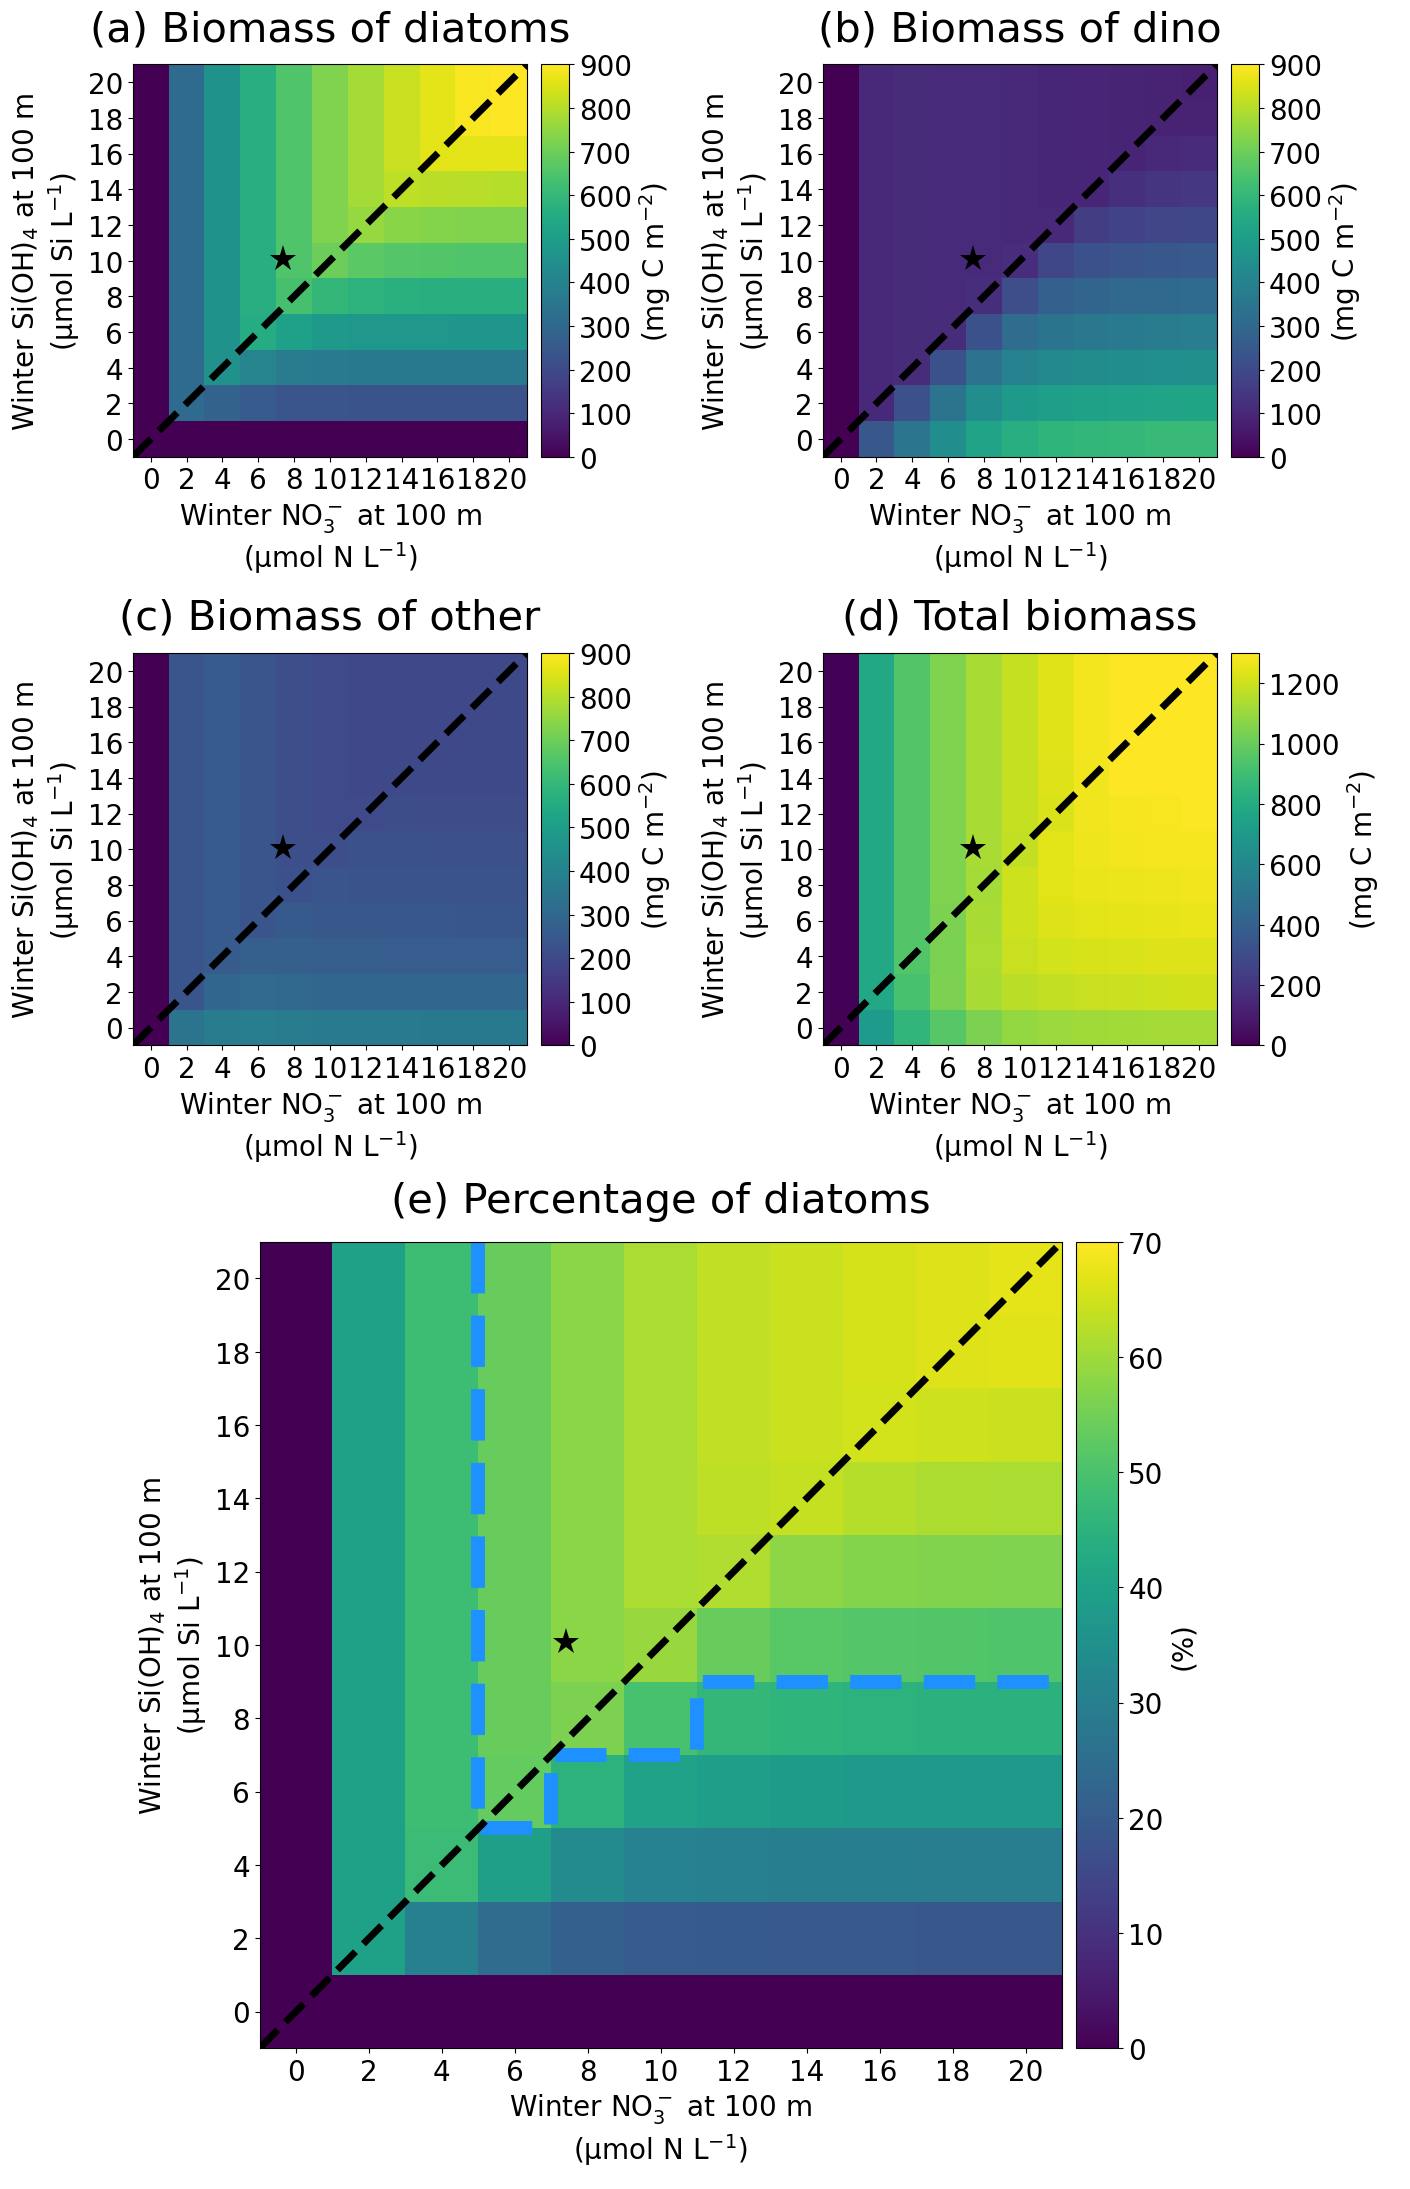

In [35]:
def make_plots(axs):
    
    # --- BIOMASS OF DIATOMS
    ax=axs[0,0]
    h=ax.pcolormesh(imeshno3,
                    imeshsi,
                    array2d_isi_ino3_diatoms_biomass/365*1000,
                    vmin=0,
                    vmax=900)
    ax.plot(no3_standard_100m,si_standard_100m,marker=marker)
    ax.set_xticks(sims_no3)
    ax.set_yticks(sims_si)
    ax.set_xlabel('Winter $\mathrm{ NO_3^- }$ at 100 m'
                  '\n($\mathrm{ \mu mol\ N\ L^{-1} }$)')
    ax.set_ylabel('Winter $\mathrm{ Si(OH)_4 }$ at 100 m'
                  '\n($\mathrm{ \mu mol\ Si\ L^{-1} }$)')
    cbaxes = fig.add_axes([0.39,0.79, 0.02,0.18])
    cbar=plt.colorbar(h,cax = cbaxes)
    cbar.set_label('($\mathrm{mg\ C\ m^{-2} }$)')
    plt.text(0.50,1.09,'(a) Biomass of diatoms',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes, fontsize=30)
    # diagonal
    ax.plot([-1,21],[-1,21],color='black',linestyle='--',linewidth=5)
    
    # --- BIOMASS OF DINOFLAGELLATES
    ax=axs[0,1]
    h=ax.pcolormesh(imeshno3,
                    imeshsi,
                    array2d_isi_ino3_dino_biomass/365*1000,
                    vmin=0,
                    vmax=900)
    ax.plot(no3_standard_100m,si_standard_100m,marker=marker)
    ax.set_xticks(sims_no3)
    ax.set_yticks(sims_si)
    ax.set_xlabel('Winter $\mathrm{ NO_3^- }$ at 100 m'
                  '\n($\mathrm{ \mu mol\ N\ L^{-1} }$)')
    ax.set_ylabel('Winter $\mathrm{ Si(OH)_4 }$ at 100 m'
                  '\n($\mathrm{ \mu mol\ Si\ L^{-1} }$)')
    cbaxes = fig.add_axes([0.39,0.52, 0.02,0.18])
    cbar=plt.colorbar(h,cax = cbaxes)
    cbar.set_label('($\mathrm{mg\ C\ m^{-2} }$)')
    plt.text(0.50,1.09,'(b) Biomass of dino',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes, fontsize=30)
    # diagonal
    ax.plot([-1,21],[-1,21],color='black',linestyle='--',linewidth=5)
    
    # --- BIOMASS OF OTHER NANOPHYTOPLANKTON
    ax=axs[1,0]
    h=ax.pcolormesh(imeshno3,
                    imeshsi,
                    array2d_isi_ino3_other_biomass/365*1000,
                    vmin=0,
                    vmax=900)
    ax.plot(no3_standard_100m,si_standard_100m,marker=marker)
    ax.set_xticks(sims_no3)
    ax.set_yticks(sims_si)
    ax.set_xlabel('Winter $\mathrm{ NO_3^- }$ at 100 m'
                  '\n($\mathrm{ \mu mol\ N\ L^{-1} }$)')
    ax.set_ylabel('Winter $\mathrm{ Si(OH)_4 }$ at 100 m'
                  '\n($\mathrm{ \mu mol\ Si\ L^{-1} }$)')
    cbaxes = fig.add_axes([0.88,0.79, 0.02,0.18])
    cbar=plt.colorbar(h,cax = cbaxes)
    cbar.set_label('($\mathrm{mg\ C\ m^{-2} }$)')
    plt.text(0.50,1.09,'(c) Biomass of other',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes, fontsize=30)
    # diagonal
    ax.plot([-1,21],[-1,21],color='black',linestyle='--',linewidth=5)
    
    # --- TOTAL BIOMASS
    ax=axs[1,1]
    h=ax.pcolormesh(imeshno3,
                    imeshsi,
                    array2d_isi_ino3_total_biomass/365*1000,
                    vmin=0,
                    vmax=1300)
    ax.plot(no3_standard_100m,si_standard_100m,marker=marker)
    ax.set_xticks(sims_no3)
    ax.set_yticks(sims_si)
    ax.set_xlabel('Winter $\mathrm{ NO_3^- }$ at 100 m'
                  '\n($\mathrm{ \mu mol\ N\ L^{-1} }$)')
    ax.set_ylabel('Winter $\mathrm{ Si(OH)_4 }$ at 100 m'
                  '\n($\mathrm{ \mu mol\ Si\ L^{-1} }$)')
    cbaxes = fig.add_axes([0.88,0.52, 0.02,0.18])
    cbar=plt.colorbar(h,cax = cbaxes)
    cbar.set_label('($\mathrm{mg\ C\ m^{-2} }$)')
    plt.text(0.50,1.09,'(d) Total biomass',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes, fontsize=30)
    # diagonal
    ax.plot([-1,21],[-1,21],color='black',linestyle='--',linewidth=5)
    
    # --- PERCENTAGE OF DIATOMS
    ax=axs[2,0]
    h=ax.pcolormesh(imeshno3,
                    imeshsi,
                    array2d_isi_ino3_diatoms_perc,
                    vmin=0,
                    vmax=70)
    ax.plot(no3_standard_100m,si_standard_100m,marker=marker)
    ax.set_xticks(sims_no3)
    ax.set_yticks(sims_si)
    ax.set_xlabel('Winter $\mathrm{ NO_3^- }$ at 100 m'
                  '\n($\mathrm{ \mu mol\ N\ L^{-1} }$)')
    ax.set_ylabel('Winter $\mathrm{ Si(OH)_4 }$ at 100 m'
                  '\n($\mathrm{ \mu mol\ Si\ L^{-1} }$)')
    cbaxes = fig.add_axes([0.77,0.06, 0.03,0.37])
    cbar=plt.colorbar(h,cax = cbaxes)
    cbar.set_label('(%)')
    plt.text(0.50,1.05,'(e) Percentage of diatoms',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes, fontsize=30)
    
    # enclose region where diatoms > 50%
    h=ax.plot(np.array(df.x),np.array(df.y),
              color='dodgerblue',linestyle='--')
    # diagonal
    ax.plot([-1,21],[-1,21],color='black',linestyle='--',linewidth=5)
    
    # --- NOTHING
    ax=axs[2,1]
    ax.axis('off')
    
    # --- POSITION
    axs[0,0].set_position([0.10,0.79, 0.28,0.18])
    axs[0,1].set_position([0.59,0.79, 0.28,0.18])
    axs[1,0].set_position([0.10,0.52, 0.28,0.18])
    axs[1,1].set_position([0.59,0.52, 0.28,0.18])
    axs[2,0].set_position([0.19,0.06, 0.57,0.37])
    axs[2,1].set_position([0.99,0.00, 0.01,0.01])

with plt.style.context('mplstyles/groups_exp2_3.mplstyle'):
    # Plot
    fig,axs=plt.subplots(nrows=3,ncols=2,figsize=(14.08,21.80))
    make_plots(axs)

    # --- SAVE
    outfile='figures/figure2.'+ext
    plt.savefig(outfile,dpi=dpi)

# Relative contribution of diatoms

In [36]:
circles={
    'circleIa':  {'x': 2,'y':14,'color':'black'},
    'circleIIa': {'x': 8,'y':14,'color':'black'},
    'circleIIb': {'x':16,'y':14,'color':'white'},
    'circleIIc': {'x':20,'y':14,'color':'white'},
    'circleIb':  {'x': 2,'y': 8,'color':'white'},
    'circleIIIa':{'x': 8,'y': 8,'color':'black'},
    'circleIVa': {'x':16,'y': 8,'color':'black'},
    'circleVa':  {'x': 2,'y': 2,'color':'black'},
    'circleVIa': {'x': 8,'y': 2,'color':'black'},
    'circleVIb': {'x':16,'y': 2,'color':'white'},
}
offset=0.1
domains={
    'domainI':{
        'vertices':np.array([[1,21-offset],
                             [1,5],
                             [5,5],
                             [5,21-offset]]),
        'text':    {'x':3,  'y':17, 'str':'I'}
    },
    'domainII':{
        'vertices':np.array([[5,21-offset],
                             [5,9],
                             [21-offset,9],
                             [21-offset,21-offset]]),
        'text':    {'x':13, 'y':17, 'str':'II'}
    },
    'domainIII':{
        'vertices':np.array([[5,9],
                             [5,5],
                             [9,5],
                             [9,9]]),
        'text':    {'x':7,  'y':7,  'str':'III'}
    },
    'domainIV':{
        'vertices':np.array([[9,9],
                             [9,5],
                             [21-offset,5],
                             [21-offset,9]]),
        'text':    {'x':15, 'y':7,  'str':'IV'}
    },
    'domainV':{
        'vertices':np.array([[1,5],
                             [1,-1+offset],
                             [5,-1+offset],
                             [5,5]]),
        'text':    {'x':3,  'y':2,  'str':'V'}
    },
    'domainVI':{
        'vertices':np.array([[5,5],
                             [5,-1+offset],
                             [21-offset,-1+offset],
                             [21-offset,5]]),
        'text':    {'x':13, 'y':2,  'str':'VI'}
    },
}

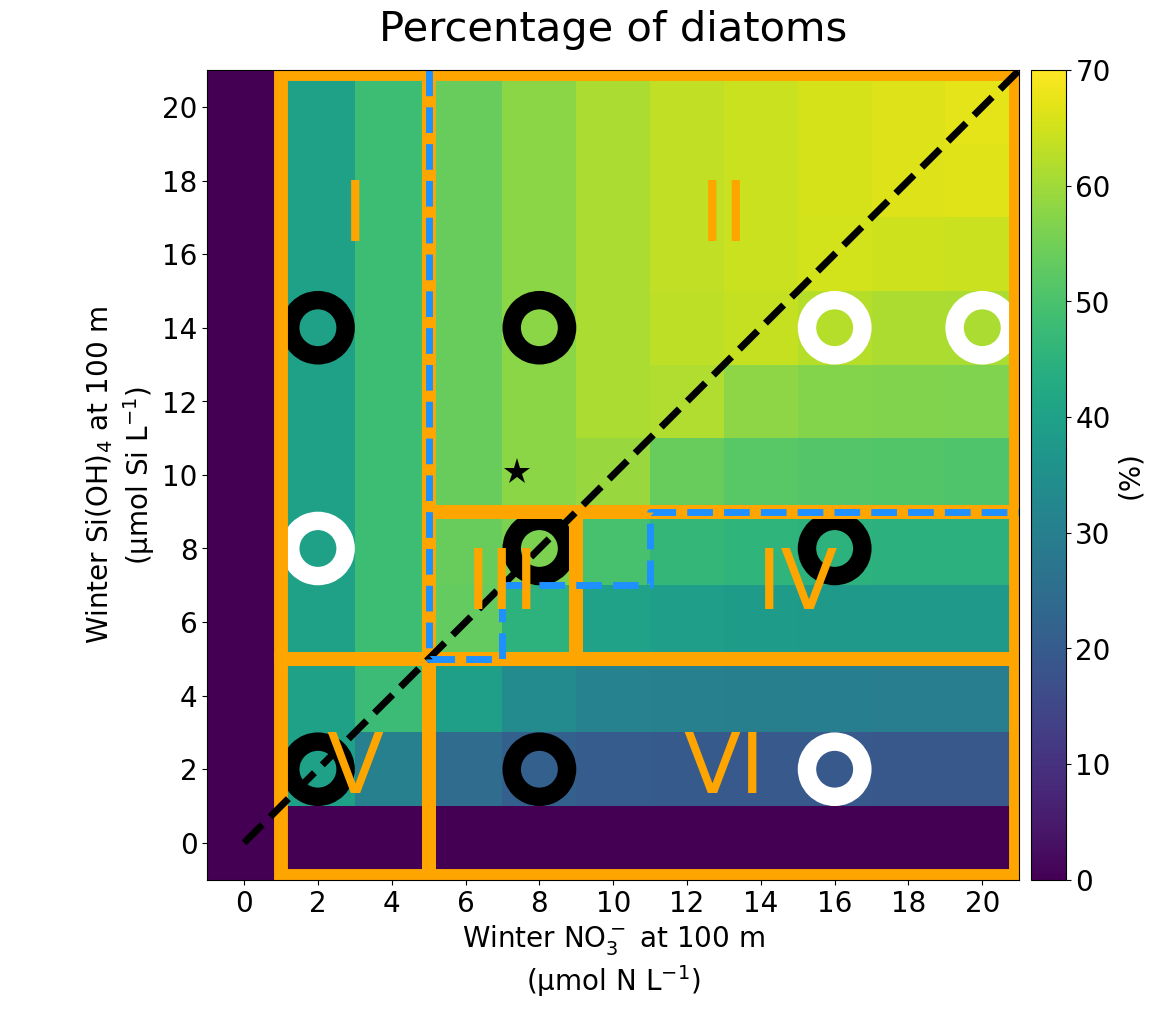

In [37]:
def make_plots(ax):
    
    # --- PERCENTAGE OF DIATOMS
    ax=axs[0]
    h=ax.pcolormesh(imeshno3,
                    imeshsi,
                    array2d_isi_ino3_diatoms_perc,
                    vmin=0,
                    vmax=70)
    ax.plot(no3_standard_100m,si_standard_100m,marker=marker)
    ax.set_xticks(sims_no3)
    ax.set_yticks(sims_si)
    ax.set_xlabel('Winter $\mathrm{ NO_3^- }$ at 100 m'
                  '\n($\mathrm{ \mu mol\ N\ L^{-1} }$)')
    ax.set_ylabel('Winter $\mathrm{ Si(OH)_4 }$ at 100 m'
                  '\n($\mathrm{ \mu mol\ Si\ L^{-1} }$)')
    cbaxes = fig.add_axes([0.88,0.11, 0.03,0.71])
    cbar=plt.colorbar(h,cax = cbaxes)
    cbar.set_label('(%)')
    plt.text(0.50,1.05,'Percentage of diatoms',
             horizontalalignment = 'center',verticalalignment='center',
             transform=ax.transAxes, fontsize=30)
    
    # --- THEORETICAL LINES
    ax.plot([0,21],[0,21],color='black',
            linestyle='--',
            linewidth=5)
    
    # --- SIMULATIONS
    patches=[]
    colors=[]
    for circle in circles.values():
        x=circle['x']
        y=circle['y']
        color=circle['color']
        wedge=mpl.patches.Wedge(center=(x,y),
                                r=1,theta1=0,theta2=360,width=0.5)
        patches.append(wedge)
        colors.append(color)
    p=mpl.collections.PatchCollection(patches,facecolors=colors)
    ax.add_collection(p)
    
    # --- DOMAINS
    patches=[]
    for domain in domains.values():
        vertices=domain['vertices']
        text=domain['text']
        polygon=mpl.patches.Polygon(vertices,
                                    edgecolor='orange',fill=False,
                                   linewidth=10)
        ax.add_patch(polygon)
        ax.text(text['x'],text['y'],text['str'],
                color='orange',
                horizontalalignment='center',
                verticalalignment='center')
    
    
    # --- ENCLOSE REGION WHERE DIATOMS > 50%
    h=ax.plot(np.array(df.x),np.array(df.y),
              color='dodgerblue',linestyle='--')
    
    # --- NOTHING
    ax=axs[1]
    ax.axis('off')
    
    # --- POSITION
    axs[0].set_position([0.17,0.11, 0.70,0.71])
    axs[1].set_position([0.00,0.00, 0.01,0.01])

with plt.style.context('mplstyles/domains.mplstyle'):
    # Plot
    fig,axs=plt.subplots(nrows=2,figsize=(11.60,11.40))
    make_plots(axs)

    # --- SAVE
    outfile='figures/figure3.'+ext
    plt.savefig(outfile,dpi=dpi)